Сравниваем рост словаря двух романов:

* Лев Толстой — Война и мир, 4 тома
* Фёдор Достоевский — Братья Карамазовы, 4 части

Для каждого романа анализируем как исходную, так и случайно перемешанную последовательность токенов, а затем выделяем наиболее характерные слова каждого автора по отношению относительных частот

## 0. Подготовка

In [1]:
import os
import re
import math
import random
import urllib.request
from html.parser import HTMLParser
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

WAR_AND_PEACE_URLS = [
    'http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0040.shtml',
    'http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0050.shtml',
    'http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0060.shtml',
    'http://az.lib.ru/t/tolstoj_lew_nikolaewich/text_0070.shtml',
]

BROTHERS_KARAMAZOV_URLS = [
    'http://az.lib.ru/d/dostoewskij_f_m/text_0100.shtml',
    'http://az.lib.ru/d/dostoewskij_f_m/text_0110.shtml',
    'http://az.lib.ru/d/dostoewskij_f_m/text_0120.shtml',
    'http://az.lib.ru/d/dostoewskij_f_m/text_0130.shtml',
]

CACHE_DIR = 'bonus_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

## 1. Скачивание и извлечение текста

az.lib.ru отдаёт страницы в кодировке windows-1251. Скачиваем каждую главу и убираем HTML простым HTMLParser (теги абзацев превращаем в переносы строк, чтобы не склеивались соседние предложения).

In [ ]:
class TextExtractor(HTMLParser):
    BREAK_TAGS = {'p', 'br', 'div', 'h1', 'h2', 'h3', 'li', 'tr', 'dd'}
    SKIP_TAGS  = {'script', 'style', 'head'}

    def __init__(self):
        super().__init__()
        self.parts = []
        self.skip_depth = 0
    def handle_starttag(self, tag, attrs):
        if tag in self.SKIP_TAGS:
            self.skip_depth += 1
        elif tag in self.BREAK_TAGS:
            self.parts.append('\n')
    def handle_endtag(self, tag):
        if tag in self.SKIP_TAGS and self.skip_depth > 0:
            self.skip_depth -= 1
    def handle_data(self, data):
        if self.skip_depth == 0:
            self.parts.append(data)

def download_chapter(url):
    print(f'  downloading {url}')
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=30) as r:
        raw = r.read()
    try:
        html = raw.decode('windows-1251')
    except UnicodeDecodeError:
        html = raw.decode('utf-8', errors='replace')
    e = TextExtractor()
    e.feed(html)
    text = ''.join(e.parts)
    text = re.sub(r'\n{2,}', '\n', text)
    return text.strip()

def download_book(urls, name):
    print(f'== {name} ==')
    chapters = [download_chapter(u) for u in urls]
    full = '\n'.join(chapters)
    print(f'  total characters: {len(full):,}')
    out_path = os.path.join(CACHE_DIR, name + '.txt')
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(full)
    return full

war_and_peace_text    = download_book(WAR_AND_PEACE_URLS,    'voyna_i_mir')
brothers_karamazov_tx = download_book(BROTHERS_KARAMAZOV_URLS, 'bratya_karamazovy')

== voyna_i_mir ==
  cache hit   http_az_lib_ru_t_tolstoj_lew_nikolaewich_text_0040_shtml.html
  cache hit   http_az_lib_ru_t_tolstoj_lew_nikolaewich_text_0050_shtml.html
  cache hit   http_az_lib_ru_t_tolstoj_lew_nikolaewich_text_0060_shtml.html
  cache hit   http_az_lib_ru_t_tolstoj_lew_nikolaewich_text_0070_shtml.html
  total characters: 3,679,142
== bratya_karamazovy ==
  cache hit   http_az_lib_ru_d_dostoewskij_f_m_text_0100_shtml.html
  cache hit   http_az_lib_ru_d_dostoewskij_f_m_text_0110_shtml.html
  cache hit   http_az_lib_ru_d_dostoewskij_f_m_text_0120_shtml.html
  cache hit   http_az_lib_ru_d_dostoewskij_f_m_text_0130_shtml.html


  total characters: 1,841,632


## 2. Токенизация и базовая статистика


Приводим к нижнему регистру, убираем пунктуацию и оставляем только последовательности кириллических букв, также нормализуем ё - е

In [3]:
TOKEN_RE = re.compile(r'[а-яa-z]+', re.IGNORECASE)

def tokenize(text):
    text = text.lower().replace('ё', 'е')
    return TOKEN_RE.findall(text)

wp_tokens = tokenize(war_and_peace_text)
bk_tokens = tokenize(brothers_karamazov_tx)

def basic_stats(name, tokens):
    n = len(tokens)
    c = Counter(tokens)
    v = len(c)
    total_chars_occ = sum(len(w) * k for w, k in c.items())
    total_chars_uni = sum(len(w) for w in c)
    return {
        'name': name,
        'tokens': n,
        'types' : v,
        'avg_token_len': total_chars_occ / n,
        'avg_type_len' : total_chars_uni / v,
        'TTR (V/N)'    : v / n,
        'hapax_frac'   : sum(1 for k in c.values() if k == 1) / v,
    }, c

wp_stats, wp_freq = basic_stats('War and Peace',       wp_tokens)
bk_stats, bk_freq = basic_stats('Brothers Karamazov',  bk_tokens)

print(f'{"":<22}{"War & Peace":>16}{"Karamazov":>16}')
for key in ('tokens', 'types', 'avg_token_len', 'avg_type_len', 'TTR (V/N)', 'hapax_frac'):
    a = wp_stats[key]
    b = bk_stats[key]
    if isinstance(a, float):
        print(f'{key:<22}{a:>16.4f}{b:>16.4f}')
    else:
        print(f'{key:<22}{a:>16,}{b:>16,}')

                           War & Peace       Karamazov
tokens                         556,438         298,037
types                           55,500          36,170
avg_token_len                   5.0023          4.7826
avg_type_len                    8.3468          8.2026
TTR (V/N)                       0.0997          0.1214
hapax_frac                      0.5109          0.5583


## 3. Рост словаря — исходный vs. перемешанный

Проходим по каждому роману токен за токеном и в логарифмически распределённых точках фиксируем пары (просмотрено токенов, увидено различных типов)

Перемешивание токенов проверяет, действительно ли кривая роста подчиняется закону Хипса, или важен исходный порядок (например, тематические сдвиги по главам)

corpus                         N       V         K    beta
Tolstoy (orig.)          556,438  55,500      3.39   0.751
Tolstoy (shuf.)          556,438  55,500      3.67   0.748
Dostoevsky (orig.)       298,037  36,170      2.83   0.765
Dostoevsky (shuf.)       298,037  36,170      3.31   0.754


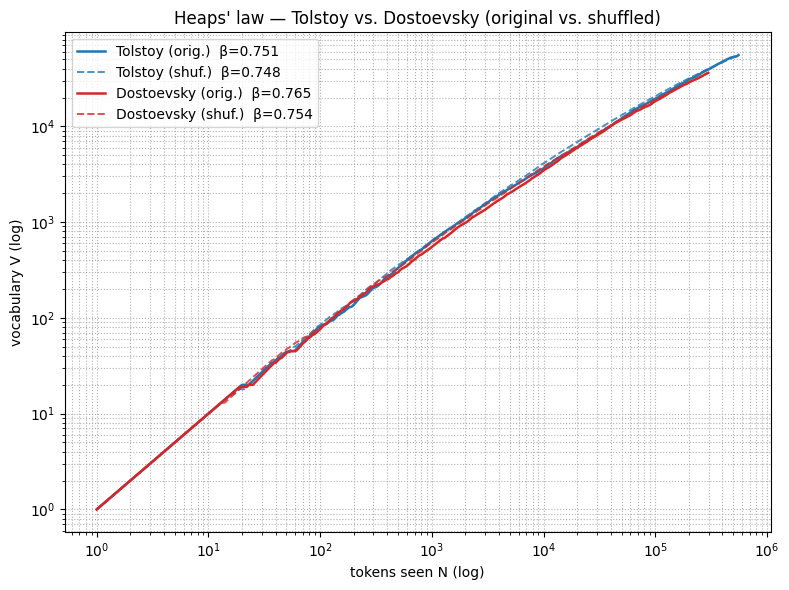

In [4]:
def vocab_growth(tokens, n_points=400):
    n = len(tokens)
    points = np.unique(np.geomspace(1, n, num=n_points).astype(np.int64))
    points_set = set(points.tolist())
    seen = set()
    xs, ys = [], []
    for i, w in enumerate(tokens, 1):
        seen.add(w)
        if i in points_set:
            xs.append(i); ys.append(len(seen))
    if xs[-1] != n:
        xs.append(n); ys.append(len(seen))
    return np.array(xs), np.array(ys)

def fit_heaps(xs, ys, x_min=200):
    mask = xs >= x_min
    beta, logK = np.polyfit(np.log10(xs[mask]), np.log10(ys[mask]), 1)
    return 10 ** logK, beta

def shuffled_copy(tokens, seed):
    arr = tokens.copy()
    rng = random.Random(seed)
    rng.shuffle(arr)
    return arr

wp_shuf = shuffled_copy(wp_tokens, seed=RNG_SEED)
bk_shuf = shuffled_copy(bk_tokens, seed=RNG_SEED)

curves = {
    'Tolstoy (orig.)'   : vocab_growth(wp_tokens),
    'Tolstoy (shuf.)'   : vocab_growth(wp_shuf),
    'Dostoevsky (orig.)': vocab_growth(bk_tokens),
    'Dostoevsky (shuf.)': vocab_growth(bk_shuf),
}

plt.figure(figsize=(8, 6))
styles = {
    'Tolstoy (orig.)'   : dict(color='C0', ls='-',  lw=1.8),
    'Tolstoy (shuf.)'   : dict(color='C0', ls='--', lw=1.4, alpha=0.8),
    'Dostoevsky (orig.)': dict(color='C3', ls='-',  lw=1.8),
    'Dostoevsky (shuf.)': dict(color='C3', ls='--', lw=1.4, alpha=0.8),
}

print(f'{"corpus":<22}{"N":>10}{"V":>8}{"K":>10}{"beta":>8}')
for label, (xs, ys) in curves.items():
    K, beta = fit_heaps(xs, ys)
    plt.loglog(xs, ys, label=f'{label}  β={beta:.3f}', **styles[label])
    print(f'{label:<22}{xs[-1]:>10,}{ys[-1]:>8,}{K:>10.2f}{beta:>8.3f}')

plt.xlabel('tokens seen N (log)')
plt.ylabel('vocabulary V (log)')
plt.title("Heaps' law — Tolstoy vs. Dostoevsky (original vs. shuffled)")
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

Выводы

* Оба автора дают практически одинаковые показатели Хипса; рост устойчив

* Перемешивание токенов почти не двигает кривую. Это согласуется с тем, что закон Хипса — свойство распределения частот униграмм, а не порядка предложений

* Прямое сравнение V–N показывает, чей словарь богаче при одинаковом размере корпуса: берём финальное V для более короткого романа, находим ту же x‑координату на другой кривой и сравниваем

In [5]:
# Compare vocabularies at the length of the shorter book (like-for-like).
n_min = min(len(wp_tokens), len(bk_tokens))
wp_V_at = len(set(wp_tokens[:n_min]))
bk_V_at = len(set(bk_tokens[:n_min]))
print(f'At the first N = {n_min:,} tokens:')
print(f'  Tolstoy:    V = {wp_V_at:>8,}')
print(f'  Dostoevsky: V = {bk_V_at:>8,}')

At the first N = 298,037 tokens:
  Tolstoy:    V =   39,194
  Dostoevsky: V =   36,170


## 4. Характерные слова каждого автора

Для каждого слова, встречающегося в корпусе не менее 20 раз, ранжируем слова по отношению относительных частот в двух корпусах


In [ ]:
def characteristic_words(freq_a, freq_b, top=25, min_count=20):
    """Words specific to A, ranked by ratio of relative frequencies in A vs. B.
    +1 smoothing in B avoids division by zero for words absent from B."""
    n_a = sum(freq_a.values())
    n_b = sum(freq_b.values())
    rows = []
    for w, ca in freq_a.items():
        if ca < min_count:
            continue
        cb = freq_b.get(w, 0)
        score = (ca / n_a) / ((cb + 1) / n_b)
        rows.append((w, ca, cb, score))
    rows.sort(key=lambda r: r[3], reverse=True)
    return rows[:top]

def print_top(rows, title):
    print(title)
    print(f'{"word":<18}{"in A":>10}{"in B":>10}{"score":>10}')
    for w, ca, cb, s in rows:
        print(f'{w:<18}{ca:>10}{cb:>10}{s:>10.2f}')
    print()

print_top(characteristic_words(wp_freq, bk_freq),
          '==> Most characteristic words of TOLSTOY (vs. Dostoevsky)')
print_top(characteristic_words(bk_freq, wp_freq),
          '==> Most characteristic words of DOSTOEVSKY (vs. Tolstoy)')


==> Most characteristic words of TOLSTOY (vs. Dostoevsky)
word                    in A      in B     score
стр                     3525         0   1888.05
строка                  3441         0   1843.05
изд                     2763         0   1479.91
чт                      2142         0   1147.29
пьер                    1574         0    843.06
пьера                    604         0    323.51
ростов                   602         0    322.44
княжна                   595         0    318.69
князь                   1592         2    284.23
граф                     497         0    266.20
сноске                   395         0    211.57
ч                        355         0    190.14
гл                       354         0    189.61
кутузов                  351         0    188.00
денисов                  332         0    177.82
графиня                  330         0    176.75
французов                303         0    162.29
войска                   302         0    161.76
соня       

Выводы

Списки доминируются именами собственными и тематической лексикой, специфической для каждого романа:

* **Толстой.Война и мир** — действующие лица романа вместе с аристократическим/военным окружением. Несколько верхних позиций (`стр`, `строка`, `изд`, `сноске`, `гл`, `ч`) — это редакционный аппарат, сноски издания;

* **Достоевский. Братья Карамазовы** — снова персонажи: трое братьев, второстепенные персонажи, польская форма обращения `пан`. Слова, не являющиеся именами, выдают Достоевского: `воскликнул`, `вскричал` и разговорные маркеры `дескать`, `давеча`, `мигом`, `подлец`.

## Выводы

1. Оба романа подчиняются закону Хипса с почти одинаковыми показателями β ≈ 0.75, так что ни один из авторов не является измеримо лексически богаче по темпу

2. При одинаковой длине корпуса у "Войны и мира" примерно на 8% больше уникальных слов, чем у "Братьев Карамазовых".

3. Перемешивание токенов оставляет кривую Хипса практически неизменной (β меняется не более чем на 0.02 в обоих романах): рост словаря определяется распределением частот униграмм, а не порядком.

4. Ранжирование по отношению относительных частот выявляет именованные сущности и тематическую лексику каждого романа.